In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dataset Load

In [2]:
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

df = pd.concat([train_df, test_df], ignore_index=True)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df.shape

(3333, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

# Target Column

In [5]:
df['Churn'].value_counts()

Churn
False    2850
True      483
Name: count, dtype: int64

# Missing Values Check

In [6]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

# Preprocessing

In [7]:
df['International plan'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
df['Voice mail plan'].unique()

array(['Yes', 'No'], dtype=object)

# LabelEncoder Use

In [9]:
le = LabelEncoder()

df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])

df[['International plan', 'Voice mail plan', 'Churn']].head()

,International plan,Voice mail plan,Churn
0,0,1,0
1,0,1,0
2,0,0,0
3,1,0,0
4,1,0,0


# Remove the 'State' and 'Area code' columns

In [10]:
df = df.drop(['State', 'Area code'], axis=1)
df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [12]:
X.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


# Feature Scaling

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled[:3]

array([[ 0.67648946, -0.32758048,  1.6170861 ,  1.23488274,  1.56676695,
         0.47664315,  1.56703625, -0.07060962, -0.05594035, -0.07042665,
         0.86674322, -0.46549436,  0.86602851, -0.08500823, -0.60119509,
        -0.0856905 , -0.42793202],
       [ 0.14906505, -0.32758048,  1.6170861 ,  1.30794844, -0.33373776,
         1.12450284, -0.33401297, -0.10808036,  0.14486653, -0.10754944,
         1.05857074,  0.14782467,  1.05938994,  1.24048169, -0.60119509,
         1.2411686 , -0.42793202],
       [ 0.9025285 , -0.32758048, -0.61839626, -0.59175986,  1.16830364,
         0.67598459,  1.168464  , -1.57338336,  0.49627857, -1.57389963,
        -0.75686906,  0.19893459, -0.75557074,  0.70312091,  0.21153386,
         0.69715637, -1.1882185 ]])

# Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
print(X_train.shape, X_test.shape)

(2666, 17) (667, 17)


# Decision Tree Train

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Prediction and Evaluate

In [18]:
dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1-score:", f1_score(y_test, dt_pred))

Accuracy: 0.9115442278860569
Precision: 0.6938775510204082
Recall: 0.7010309278350515
F1-score: 0.6974358974358974


# Logistic Regression Train

In [19]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Prediction and Evaluate

In [20]:
lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1-score:", f1_score(y_test, lr_pred))

Accuracy: 0.8605697151424287
Precision: 0.5526315789473685
Recall: 0.21649484536082475
F1-score: 0.3111111111111111


# Random Forest Train

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction and Evaluate

In [22]:
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))

Accuracy: 0.9490254872563718
Precision: 0.9565217391304348
Recall: 0.6804123711340206
F1-score: 0.7951807228915663


# GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV

# Make Parameter Grid

In [24]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Run GridSearch

In [25]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


# Best Parameters

In [26]:
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

In [27]:
grid_search.best_score_

np.float64(0.8188927220573458)

# Final Evaluation

In [28]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1-score:", f1_score(y_test, best_pred))

Accuracy: 0.9550224887556222
Precision: 0.971830985915493
Recall: 0.711340206185567
F1-score: 0.8214285714285714


# Model Comparison Bar Chart

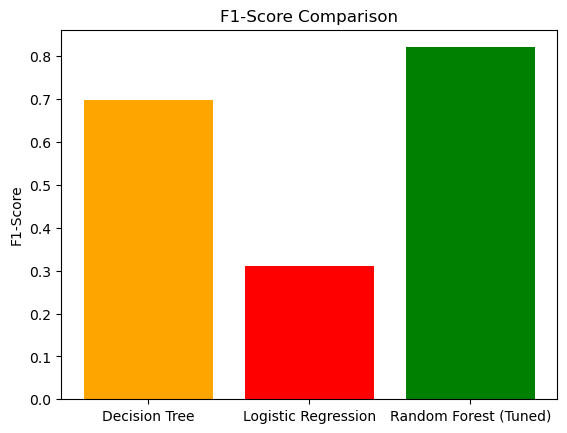

In [29]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Logistic Regression', 'Random Forest (Tuned)']
f1_scores = [0.697, 0.311, 0.821]

plt.bar(models, f1_scores, color=['orange', 'red', 'green'])
plt.title("F1-Score Comparison")
plt.ylabel("F1-Score")
plt.show()